In [5]:
# Install required dependencies if not already present in the active Jupyter kernel
%pip install -q imbalanced-learn xgboost


Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, roc_curve

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [7]:
df = pd.read_csv('datasets/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.info()
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [9]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(pd.Series(y_train_smote).value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [11]:
svm_model = LinearSVC(C=0.01, random_state=42, max_iter=2000, dual=False)
svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test_scaled)
print("Baseline SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Baseline SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Confusion Matrix:
[[55579  1285]
 [    9    89]]


In [12]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = (y_pred_proba_xgb >= 0.5).astype(int)

print("XGBoost (Threshold = 0.5) Classification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, y_pred_proba_xgb):.4f}")

XGBoost (Threshold = 0.5) Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.25      0.88      0.39        98

    accuracy                           1.00     56962
   macro avg       0.63      0.94      0.69     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56609   255]
 [   12    86]]
ROC-AUC: 0.9799
PR-AUC (Average Precision): 0.8055


Optimal Threshold: 0.9772
Optimal F1 Score: 0.8377


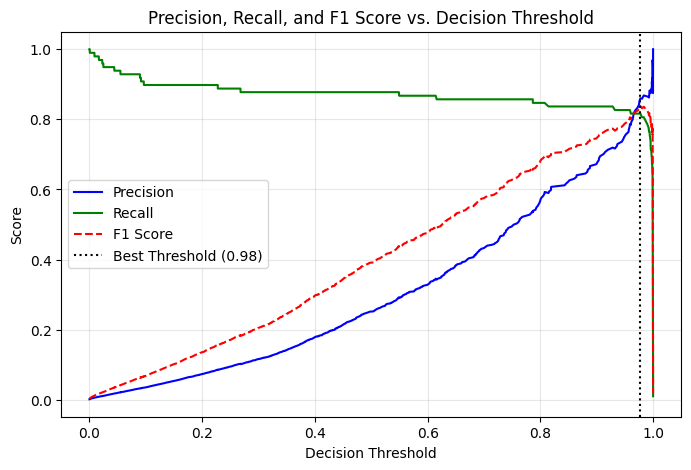

In [13]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Optimal F1 Score: {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores, label='F1 Score', color='red', linestyle='--')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Best Threshold ({best_threshold:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Decision Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
y_pred_tuned = (y_pred_proba_xgb >= best_threshold).astype(int)

print(f"XGBoost (Tuned Threshold = {best_threshold:.4f}) Classification Report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

XGBoost (Tuned Threshold = 0.9772) Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56851    13]
 [   18    80]]


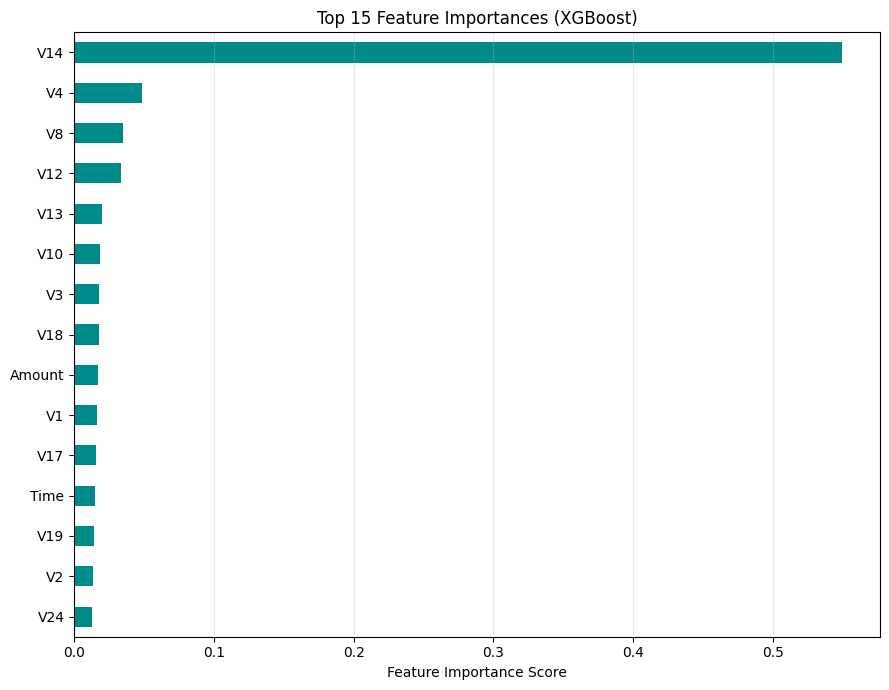

In [15]:
importance_series = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 7))
importance_series.tail(15).plot(kind='barh', color='darkcyan')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

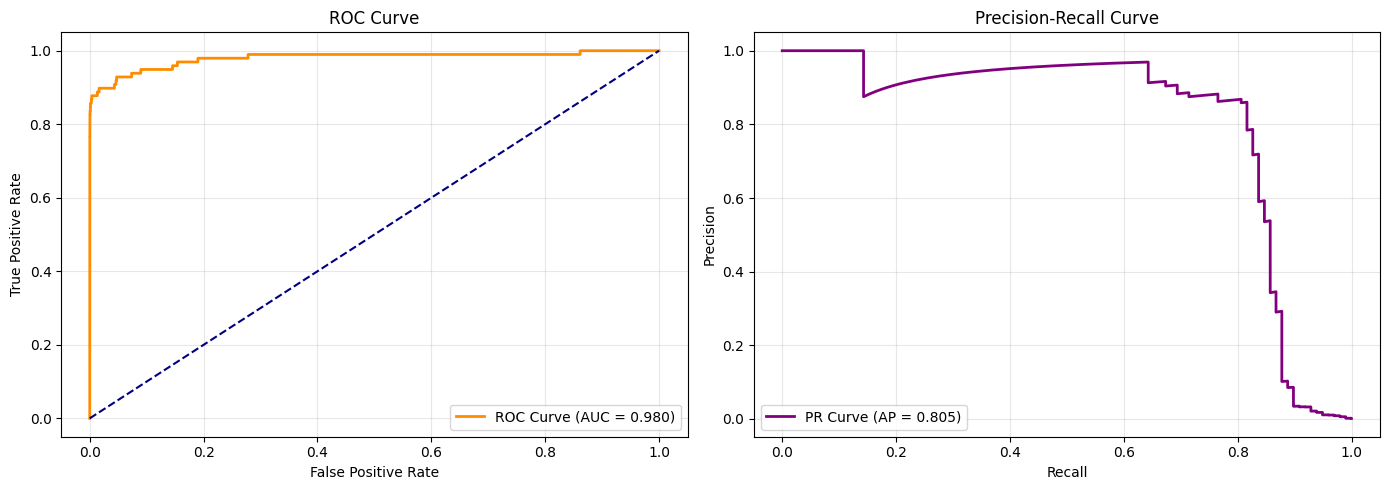

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].plot(recalls, precisions, color='purple', lw=2, label=f'PR Curve (AP = {average_precision_score(y_test, y_pred_proba_xgb):.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()